In [1]:
import pandas as pd

main_df = pd.read_csv("owid_climate_data.csv")
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26182 entries, 0 to 26181
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country Name                26182 non-null  str    
 1   Country Code                22895 non-null  str    
 2   Year                        26182 non-null  int64  
 3   CO2 Emissions Per Capita    26182 non-null  float64
 4   Annual Temperature Anomaly  14319 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1022.9 KB


In [2]:
#Step 1 Cleaning the Data Set
#Step 1.1 Inspecting if there is any NaN or missing values in the dataset before cleaning.
print("\nMissing values per column:")
print(main_df.isnull().sum()) 
print("\nThe percentage of values missing:")
print(main_df.isnull().mean() * 100)

#12.5% for Country Code missing is fine as it's just an identifier column. Not used for calculations.
#45.3% for Temperature is concerning as it is used for calculations and visualisation.


Missing values per column:
Country Name                      0
Country Code                   3287
Year                              0
CO2 Emissions Per Capita          0
Annual Temperature Anomaly    11863
dtype: int64

The percentage of values missing:
Country Name                   0.000000
Country Code                  12.554427
Year                           0.000000
CO2 Emissions Per Capita       0.000000
Annual Temperature Anomaly    45.309755
dtype: float64


In [3]:
#Step 1.2 Checking where atleast 45% of the missing temperature is missing. 
#Which years are missing annual temperature collection
missing_years = main_df[main_df['Annual Temperature Anomaly'].isna()]['Year'].describe() #Filters only the rows of Annual Temperature Anomaly that have NaN values and then calculates the summary statistics of filtered results
print(missing_years)

count    11863.000000
mean      1914.853831
std         54.309648
min       1750.000000
25%       1878.000000
50%       1913.000000
75%       1949.000000
max       2023.000000
Name: Year, dtype: float64


In [4]:
print("The mean year of missing values is 1914 — so on average, the missing temperature records are from over 100 years ago. The median (50%) is 1913 — half of all missing values come from before 1913. The 75th percentile is 1949 — meaning 75% of missing temperature values are from before 1949. The max is 2023 — so there are some recent missing values, but they're the exception.")

The mean year of missing values is 1914 — so on average, the missing temperature records are from over 100 years ago. The median (50%) is 1913 — half of all missing values come from before 1913. The 75th percentile is 1949 — meaning 75% of missing temperature values are from before 1949. The max is 2023 — so there are some recent missing values, but they're the exception.


In [5]:
#Step 1.3 Countries that have largest data gaps for temperature 
print("The countries that have largest data gaps:" )
print(main_df[main_df['Annual Temperature Anomaly'].isna()]['Country Name'].value_counts().head(10))
print("\n") 


The countries that have largest data gaps:
Country Name
Asia                            229
Asia (excl. China and India)    229
Europe                          229
Europe (excl. EU-27)            229
Europe (excl. EU-28)            229
European Union (28)             229
High-income countries           229
Oceania                         229
Taiwan                          229
North America                   225
Name: count, dtype: int64




In [6]:
#Step 1.4 Finding the total countries that are missing temperature anomaly values
total_countries = main_df['Country Name'].nunique()
data_gap_countries = main_df[main_df['Annual Temperature Anomaly'].isna()]['Country Name'].nunique()
print(f"The total amount of countries in the dataset: {total_countries}")
print("\n")
print(f"The amount of unique countries (not including country duplicates) that have largest data gaps for temperature: {data_gap_countries}")


The total amount of countries in the dataset: 231


The amount of unique countries (not including country duplicates) that have largest data gaps for temperature: 147


In [7]:
#Step 1.5 Cleaning the dataset
cleaned_df = (
    main_df
    .drop(columns=['Country Code']) #Drops Country Code column as it is not needed for our analyses
    .dropna(subset=['Annual Temperature Anomaly']) #Removes missing temperature rows
)
print(f"Rows before cleaning: {len(main_df)}")
print(f"Rows after cleaning: {len(cleaned_df)}")
print(f"Rows removed: {len(main_df) - len(cleaned_df)}")
print("\n")
print(cleaned_df.head())

#Saving cleaned dataset to CSV
cleaned_df.to_csv('cleaned_owid_climate_data.csv', index=False)
print("\n")
print('Cleaned dataset saved as cleaned_owid_climate_data.csv')



Rows before cleaning: 26182
Rows after cleaning: 14319
Rows removed: 11863


  Country Name  Year  CO2 Emissions Per Capita  Annual Temperature Anomaly
0  Afghanistan  1949                  0.001992                   -2.020418
1  Afghanistan  1950                  0.010837                   -2.298886
2  Afghanistan  1951                  0.011625                   -1.287201
3  Afghanistan  1952                  0.011468                   -1.237078
4  Afghanistan  1953                  0.013123                   -1.084867


Cleaned dataset saved as cleaned_owid_climate_data.csv


In [8]:
#Step 2 Steps & Functions
#Step 2.1 
countries_set = set(cleaned_df["Country Name"]) #Automatically removes duplicates
print(countries_set)
print(f"\nTotal unique countries: {len(countries_set)} vs Total countries with duplicates: {len(cleaned_df['Country Name'])}")


{'Tunisia', 'New Caledonia', 'Nigeria', 'Chad', 'Honduras', 'Albania', 'Argentina', 'Peru', 'Angola', 'Armenia', 'Faroe Islands', 'Moldova', 'Spain', 'Switzerland', 'Ireland', 'Philippines', 'Guyana', 'Bangladesh', 'France', 'Namibia', 'Turkey', 'Kazakhstan', 'Lithuania', 'North Macedonia', 'Belgium', 'El Salvador', 'China', 'Ecuador', 'Estonia', 'Italy', 'Samoa', 'Germany', 'Latvia', 'Mozambique', 'India', 'Mongolia', 'Kenya', 'Sudan', 'East Timor', 'Malaysia', 'Myanmar', 'Gambia', 'Djibouti', 'Guinea-Bissau', 'Sao Tome and Principe', 'Lebanon', 'North Korea', 'Kiribati', 'Democratic Republic of Congo', 'Australia', 'Gabon', 'Hong Kong', 'Brazil', 'Kosovo', 'Bahamas', 'Libya', 'Togo', 'Senegal', 'Madagascar', 'Vanuatu', 'Guatemala', 'Kyrgyzstan', 'Liberia', 'Qatar', 'Tanzania', 'Chile', 'Nicaragua', 'Nepal', 'Central African Republic', 'Uzbekistan', 'Congo', 'Romania', 'New Zealand', 'Cambodia', 'Mauritius', 'Slovakia', 'Bulgaria', 'Bosnia and Herzegovina', 'French Polynesia', 'Azerba

In [9]:
#Step 2.2 Function to retrieve rows by country and year range
def get_country_data(df, country, start_year, end_year):
    """
    Returns a filtered DataFrame for a given country and year range.

    Parameters: 
    df: any Dataframe
    country: Country name as str
    start_year: Start of year range (inclusive, int)
    end_year: End of year range (inclusive, int)
    """
    if country not in countries_set: #Validates if country exists before filtering
        print(f"'{country}' is not found in the dataset. Please check spelling or print out countries_set to check unique countries.")
        return None 
        
    filtered_country_df = df[
        (df['Country Name'] == country) &
        (df['Year'] >= start_year) &
        (df['Year'] <= end_year)
        ]
    return filtered_country_df.reset_index(drop=True)

In [10]:
#Step 2.3 Testing function
india_data = get_country_data(cleaned_df, 'India', 2000, 2020)
print(india_data)

   Country Name  Year  CO2 Emissions Per Capita  Annual Temperature Anomaly
0         India  2000                  0.932435                   -0.224110
1         India  2001                  0.928220                   -0.147684
2         India  2002                  0.940360                    0.215657
3         India  2003                  0.956066                   -0.042418
4         India  2004                  0.998095                    0.001837
5         India  2005                  1.034569                   -0.076595
6         India  2006                  1.101976                    0.174562
7         India  2007                  1.169509                    0.052127
8         India  2008                  1.233049                   -0.179187
9         India  2009                  1.315532                    0.537815
10        India  2010                  1.348904                    0.492528
11        India  2011                  1.399205                   -0.155027
12        In

In [11]:
#Step 3 Logical Filtering
#Step 3.1 Global average of CO2 emissions in 2020
global_avg_co2_2020 = cleaned_df[cleaned_df['Year'] == 2020]['CO2 Emissions Per Capita'].mean()
print(f"Global average CO2 emissions per capita in 2020: {global_avg_co2_2020:.2f} metric tonnes")

Global average CO2 emissions per capita in 2020: 4.34 metric tonnes


In [12]:
#Step 3.2 Filtering countries where CO2 emissions are above 10 metric tons in 2020 
countries_co2_above_10_2020 = cleaned_df[
    (cleaned_df['Year'] == 2020) &
    (cleaned_df['CO2 Emissions Per Capita'] > 10)
    ].reset_index(drop=True).sort_values('CO2 Emissions Per Capita', ascending=False) #From highest emitters to lowest
print(countries_co2_above_10_2020)


            Country Name  Year  CO2 Emissions Per Capita  \
11                 Qatar  2020                 36.564110   
1                Bahrain  2020                 25.215979   
2                 Brunei  2020                 24.939121   
15   Trinidad and Tobago  2020                 23.677786   
16  United Arab Emirates  2020                 23.006842   
6                 Kuwait  2020                 21.739220   
13          Saudi Arabia  2020                 19.879406   
9          New Caledonia  2020                 17.981370   
0              Australia  2020                 15.506062   
10                  Oman  2020                 15.174401   
4          Faroe Islands  2020                 14.426020   
17         United States  2020                 13.889589   
3                 Canada  2020                 13.795024   
5             Kazakhstan  2020                 13.113933   
7             Luxembourg  2020                 12.806264   
14           South Korea  2020          

In [13]:
#Step 4 Probability & Statistics
#1.5 degrees celsius was chosen due to Paris Agreement
paris_threshold = 1.5

#Step 4.1 The % of the recorded observations exceed this threshold
exceeding = cleaned_df[cleaned_df['Annual Temperature Anomaly'] > paris_threshold]
probability = (len(exceeding)) / (len(cleaned_df)) * 100

print(f"Rows exceeding 1.5 degrees: {len(exceeding)}")
print(f"Total rows in dataset: {len(cleaned_df)}")
print(f"Probability of temperature anomaly exceeding {paris_threshold}°C: {probability:.2f}%")

Rows exceeding 1.5 degrees: 49
Total rows in dataset: 14319
Probability of temperature anomaly exceeding 1.5°C: 0.34%


In [14]:
#Step 4.2 Calculating the mean, min, and max of temperature each year
aggregated_temp_per_year = (
    cleaned_df.groupby(['Year'])['Annual Temperature Anomaly'].agg(["mean", "min", "max"]))
print(aggregated_temp_per_year)

          mean       min       max
Year                              
1940 -1.624415 -3.825056  0.423903
1941 -1.251653 -3.941369  1.779448
1942 -1.368997 -3.628582  0.683115
1943 -1.021218 -2.985201  1.080043
1944 -1.000902 -2.997106  0.915558
...        ...       ...       ...
2019  0.601391 -0.226331  1.697816
2020  0.580830 -0.231912  2.247584
2021  0.411804 -0.655329  1.511456
2022  0.444629 -0.582847  1.773571
2023  0.862665 -0.266950  1.894608

[84 rows x 3 columns]


In [15]:
#Step 4.3 Calculating the change in mean temperature anomaly from 1940 to 2023
mean_1940 = aggregated_temp_per_year.loc[1940, 'mean']
mean_2023 = aggregated_temp_per_year.loc[2023, 'mean']
change = mean_2023 - mean_1940

print(f"Mean temperature anomaly in 1940: {mean_1940:.2f}°C")
print(f"Mean temperature anomaly in 2023: {mean_2023:.2f}°C")
print(f"Change in mean temperature anomaly: {change:.2f}°C")

Mean temperature anomaly in 1940: -1.62°C
Mean temperature anomaly in 2023: 0.86°C
Change in mean temperature anomaly: 2.49°C


In [16]:
#Step 5 Counting Principles
#Step 5.1 Individual counts of unique countries & years
print("Unique countries:", cleaned_df["Country Name"].nunique())
print("Unique years:", cleaned_df["Year"].nunique())

Unique countries: 187
Unique years: 84


In [17]:
#Step 5.2 Actual maximum combinations
combos = cleaned_df.groupby(['Country Name', 'Year']).size()
print(f"Number of unique country-year combinations: {len(combos)}")

Number of unique country-year combinations: 14319


In [18]:
# Step 5.3 Theoretical maximum vs actual coverage
theoretical_max = cleaned_df["Country Name"].nunique() * cleaned_df["Year"].nunique()
print(f"Theoretical maximum combinations: {theoretical_max}")
print(f"Coverage gap: {theoretical_max - len(combos)} missing combinations")
print(f"Dataset coverage: {(len(combos) / theoretical_max) * 100:.2f}%")

Theoretical maximum combinations: 15708
Coverage gap: 1389 missing combinations
Dataset coverage: 91.16%


In [19]:
#Step 6: Graph Theory & Networks
#Step 6.1 Importing networkx and matplotlib.pyplot
import matplotlib.pyplot as plt
import networkx as nx

#Step 6.2 Building the network graph using the high emitters from Step 3
G_top20= nx.Graph()
for _, row in countries_co2_above_10_2020.iterrows(): #Adding each high emitter as a node
    G_top20.add_node(row['Country Name'],
               co2=row['CO2 Emissions Per Capita']) 

for i, row_i in countries_co2_above_10_2020.iterrows(): # Draw edges between countries if CO2 emissions differ by less than 1.0 metric tonne
    for j, row_j in countries_co2_above_10_2020.iterrows():
        if i < j:  # Avoid duplicate edges and self-loops
            if abs(row_i['CO2 Emissions Per Capita'] - row_j['CO2 Emissions Per Capita']) < 1.0:
                G_top20.add_edge(row_i['Country Name'], row_j['Country Name'])

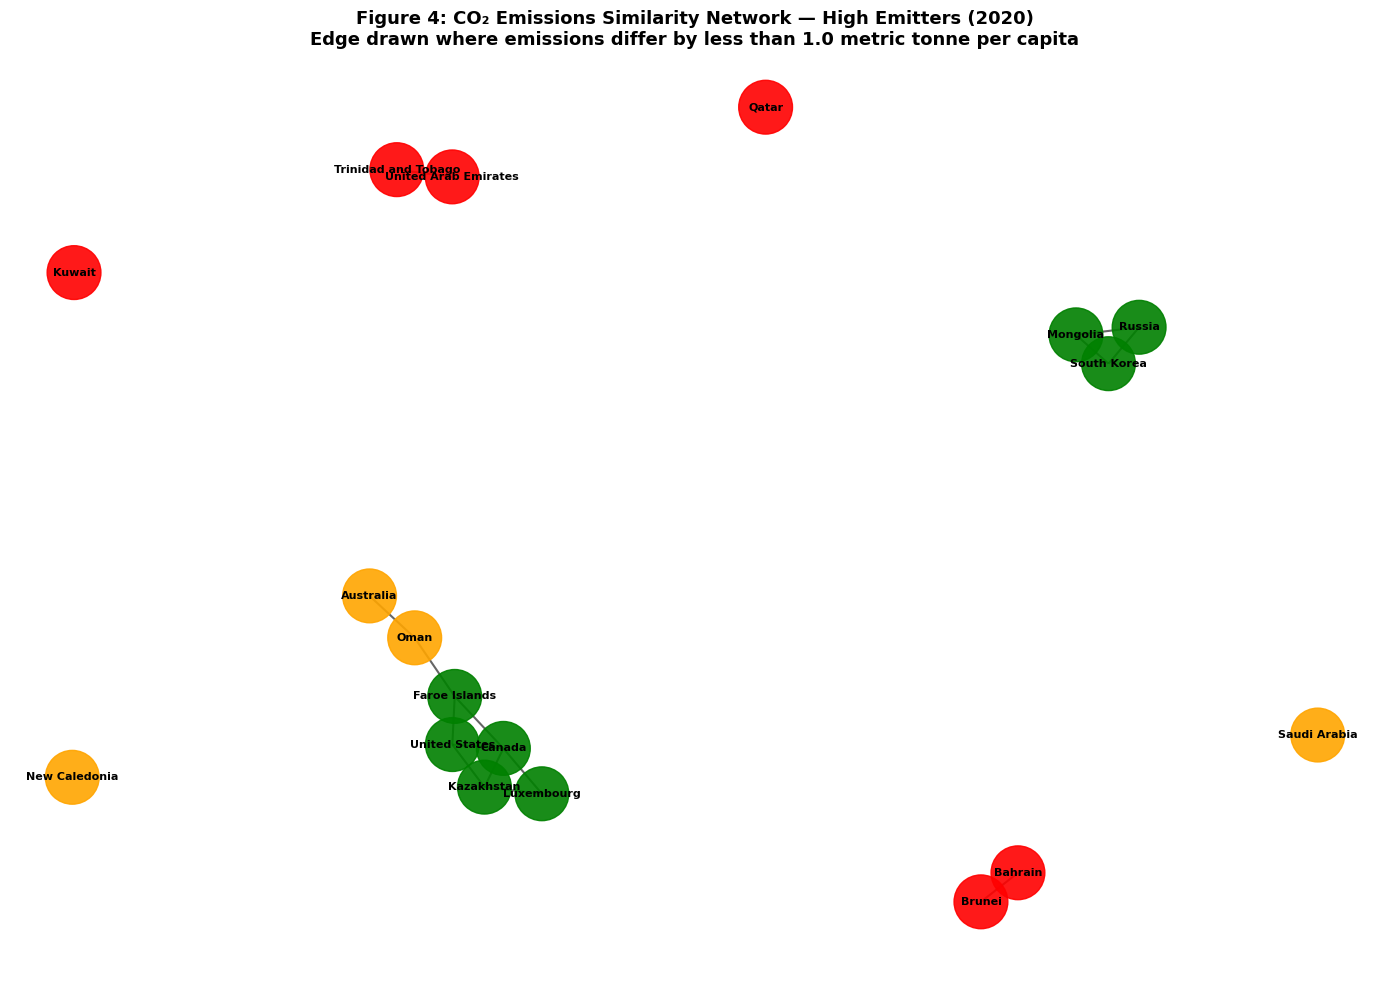

Number of nodes (countries): 18
Number of edges (similar pairs): 14
Isolated nodes (no similar peers): 4


In [20]:
#Step 6.3 Visualising the graph
fig, ax = plt.subplots(figsize=(14, 10)) 
pos = nx.spring_layout(G_top20, seed=42) #Spring layout naturally clusters similar emission countries together

#Colour coding the nodes to show the difference in their CO2 emissions
co2_values = [G_top20.nodes[node]['co2'] for node in G_top20.nodes]
node_colours = ['red' if G_top20.nodes[node]['co2']> 20
                else 'orange' if G_top20.nodes[node]['co2'] > 15
                else 'green'
                for node in G_top20.nodes]

nx.draw_networkx_nodes(G_top20, pos, node_color=node_colours, 
                       node_size=1500, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G_top20, pos, font_size=8, 
                        font_weight='bold', ax=ax)
nx.draw_networkx_edges(G_top20, pos, edge_color='black', 
                       width=1.5, alpha=0.6, ax=ax)

ax.set_title('Figure 4: CO₂ Emissions Similarity Network — High Emitters (2020)\n' #Main container
             'Edge drawn where emissions differ by less than 1.0 metric tonne per capita',
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)  #Takes away the borders of the graph, keeps it clean 
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False) #Spines removed since graph node positiosn based on layout not x-y coordinates. Showing axis borders imply posiiton of nodes has numerical meaning which it doesnt
ax.axis('off')

plt.tight_layout()
plt.savefig('fig4_network_graph.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 6.3 Print basic graph statistics
print(f"Number of nodes (countries): {G_top20.number_of_nodes()}")
print(f"Number of edges (similar pairs): {G_top20.number_of_edges()}")
print(f"Isolated nodes (no similar peers): {len(list(nx.isolates(G_top20)))}")

In [21]:
#Step 6.4 Creating a network graph for all the countries in the dataset
#Step 6.4.1 This relationship data is important for the inference recommendation step
G_all_countries = nx.Graph()
for _, row in cleaned_df.iterrows(): #Adding each country as a node
    G_all_countries.add_node(row['Country Name'],
               co2=row['CO2 Emissions Per Capita']) 

countries = list(cleaned_df['Country Name']) #Lists are faster to loop through than a DataFrame
co2_vals = list(cleaned_df['CO2 Emissions Per Capita'])

for i in range(len(countries)):                        # Outer loop: each country once
    for j in range(i + 1, len(countries)):             # Inner loop: only countries AFTER i
        # i + 1 means never compare a country to itself, and never repeat a pair
        if abs(co2_vals[i] - co2_vals[j]) < 1.0:      # Same threshold as before
            G_all_countries.add_edge(countries[i], countries[j])     # Connect similar countries

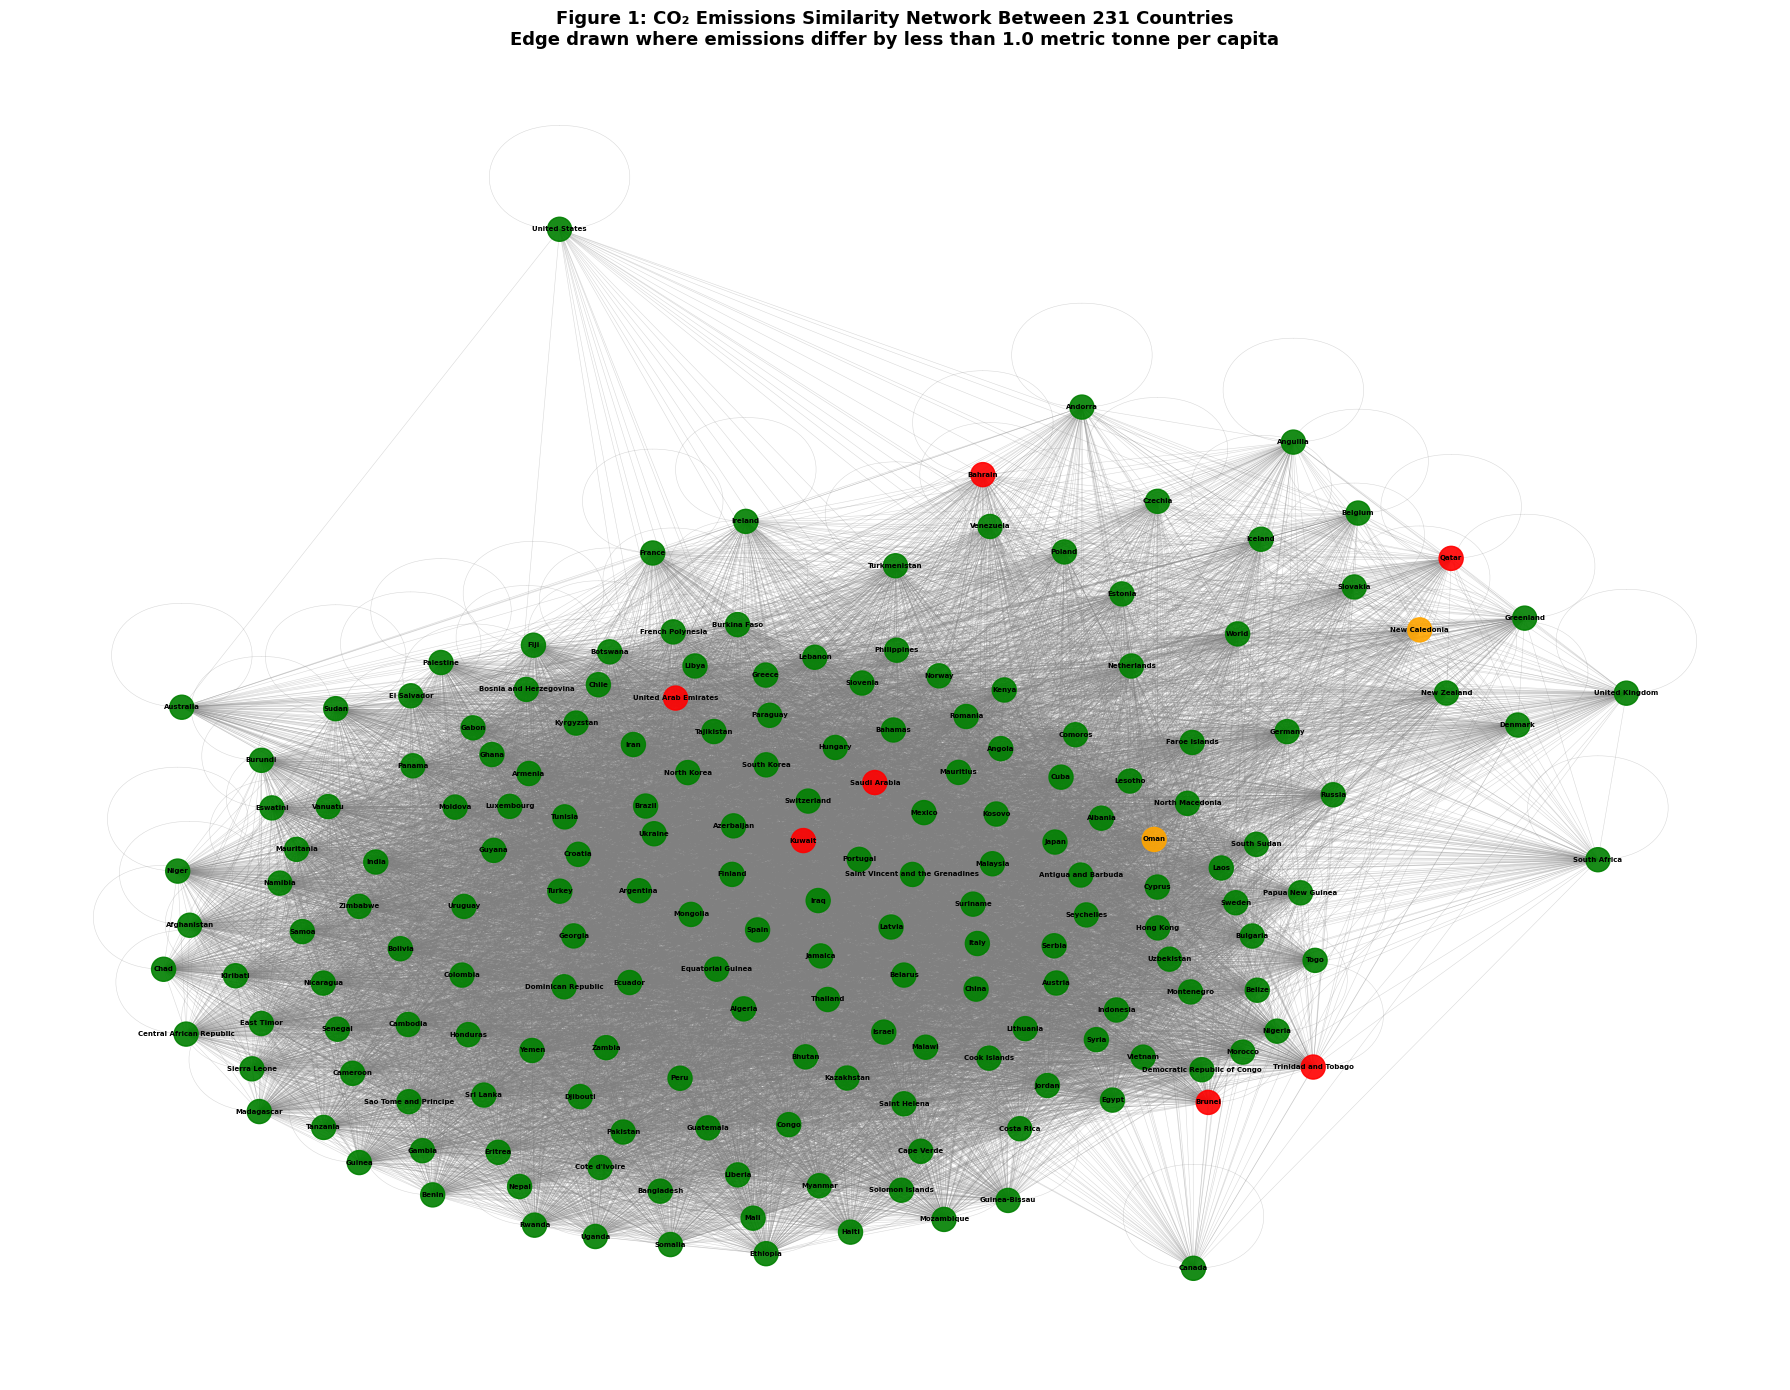

Number of nodes (countries): 187
Number of edges (similar pairs): 15456
Isolated nodes (no similar peers): 0


In [48]:
#Step 6.4.2 Visualising the overall network of the cleaned dataset
fig, ax = plt.subplots(figsize=(18, 14))
pos = nx.spring_layout(G_all_countries, seed=42, k=0.8)

node_colours = [
    'red'    if G_all_countries.nodes[node]['co2'] > 20
    else 'orange' if G_all_countries.nodes[node]['co2'] > 15
    else 'green'
    for node in G_all_countries.nodes
]

nx.draw_networkx_nodes(G_all_countries, pos, node_color=node_colours,
                       node_size=300,   # Reduced from 1500 — 231 large nodes overlap badly
                       alpha=0.9, ax=ax)
nx.draw_networkx_labels(G_all_countries, pos, font_size=5,  # Reduced — 231 labels at size 8 overlap unreadably
                        font_weight='bold', ax=ax)
nx.draw_networkx_edges(G_all_countries, pos, edge_color='grey',
                       width=0.4,   # Thinner — hundreds of edges at width 1.5 looks like a solid black blob
                       alpha=0.3, ax=ax)

ax.set_title('Figure 1: CO₂ Emissions Similarity Network Between 231 Countries\n'
             'Edge drawn where emissions differ by less than 1.0 metric tonne per capita',
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.axis('off')
plt.tight_layout()
plt.savefig('fig1_full_network_graph.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Number of nodes (countries): {G_all_countries.number_of_nodes()}")
print(f"Number of edges (similar pairs): {G_all_countries.number_of_edges()}")
print(f"Isolated nodes (no similar peers): {len(list(nx.isolates(G_all_countries)))}")

In [23]:
#Step 7 Aggregation & Visualisation
#Step 7.1 Line Chart - Average Global Temperature Anomaly Over Time
average_global_temp_by_year = cleaned_df.groupby('Year')['Annual Temperature Anomaly'].mean().reset_index()

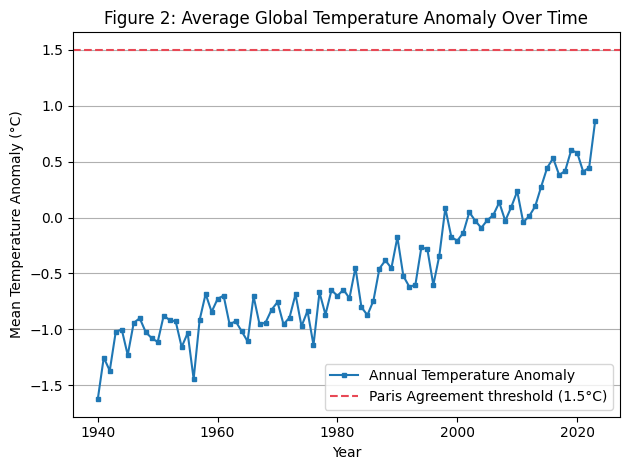

In [24]:
#Step 7.2 Line Chart of Average Temperature over Time
average_global_temp_by_year.set_index('Year')['Annual Temperature Anomaly'].plot(kind='line', marker='s', markersize='3')
plt.title('Figure 2: Average Global Temperature Anomaly Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Temperature Anomaly (°C)')
plt.grid(axis='y')
plt.axhline(y=1.5, color='#E84855', linestyle='--', 
            linewidth=1.5, label='Paris Agreement threshold (1.5°C)') #Adds a horizontal line at the threshold value of 1.5. Used as a comparison.
plt.legend()
plt.tight_layout()
plt.savefig('fig2_line_temp_trend.png', dpi=150, bbox_inches='tight') 
plt.show()

In [25]:
# Step 7.3 Creating variable that stores CO2 emissions for each country in 2020
country_co2_2020 = (
    cleaned_df[cleaned_df['Year'] == 2020]
    .groupby('Country Name')['CO2 Emissions Per Capita']
    .mean()  
    .sort_values(ascending=True)  # Ascending for horizontal readability
    .reset_index()
)

top_co2_2020 = country_co2_2020[country_co2_2020['CO2 Emissions Per Capita'] > 10]
print(top_co2_2020)

             Country Name  CO2 Emissions Per Capita
169                Russia                 11.156080
170              Mongolia                 11.265909
171           South Korea                 11.524341
172            Luxembourg                 12.806264
173            Kazakhstan                 13.113933
174                Canada                 13.795024
175         United States                 13.889589
176         Faroe Islands                 14.426020
177                  Oman                 15.174401
178             Australia                 15.506062
179         New Caledonia                 17.981370
180          Saudi Arabia                 19.879406
181                Kuwait                 21.739220
182  United Arab Emirates                 23.006842
183   Trinidad and Tobago                 23.677786
184                Brunei                 24.939121
185               Bahrain                 25.215979
186                 Qatar                 36.564110


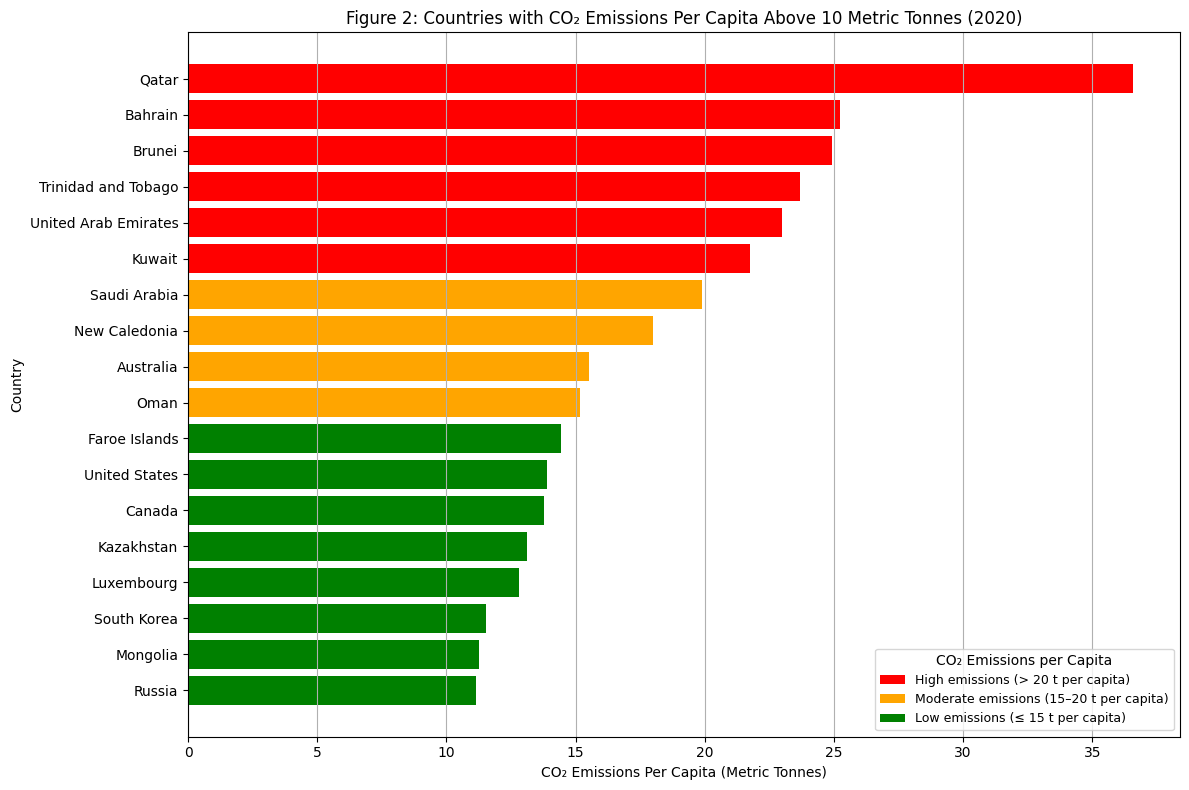

In [51]:
# Step 7.3.1 Creating the bar chart
# Colour coded to match network graph from Step 6 — red above 20t, orange 15-20t, green 10-15t
colours = ['red' if v > 20 
           else 'orange' if v > 15 
           else 'green' 
           for v in top_co2_2020['CO2 Emissions Per Capita']]
plt.figure(figsize=(12, 8))
plt.barh(top_co2_2020['Country Name'], top_co2_2020['CO2 Emissions Per Capita'], color=colours)
plt.title('Figure 2: Countries with CO₂ Emissions Per Capita Above 10 Metric Tonnes (2020)')
plt.xlabel('CO₂ Emissions Per Capita (Metric Tonnes)')
plt.ylabel('Country')
plt.grid(axis='x')

legend = [
    Patch(facecolor='red',    label='High emissions (> 20 t per capita)'),
    Patch(facecolor='orange', label='Moderate emissions (15–20 t per capita)'),
    Patch(facecolor='green',  label='Low emissions (≤ 15 t per capita)'),
]
plt.legend(handles=legend, loc='lower right', fontsize=9,
           title='CO₂ Emissions per Capita', title_fontsize=10)

plt.tight_layout()
plt.savefig('fig2_bar_top_co2_emitters.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
#Step 7.4  Filtering 2020 data for the 18 high emitting countries
# Reusing top_co2_2020 from Step 7.3 
temp_co2_2020 = cleaned_df[
    (cleaned_df['Year'] == 2020) &
    (cleaned_df['Country Name'].isin(top_co2_2020['Country Name']))
].reset_index(drop=True)
print(temp_co2_2020)

            Country Name  Year  CO2 Emissions Per Capita  \
0              Australia  2020                 15.506062   
1                Bahrain  2020                 25.215979   
2                 Brunei  2020                 24.939121   
3                 Canada  2020                 13.795024   
4          Faroe Islands  2020                 14.426020   
5             Kazakhstan  2020                 13.113933   
6                 Kuwait  2020                 21.739220   
7             Luxembourg  2020                 12.806264   
8               Mongolia  2020                 11.265909   
9          New Caledonia  2020                 17.981370   
10                  Oman  2020                 15.174401   
11                 Qatar  2020                 36.564110   
12                Russia  2020                 11.156080   
13          Saudi Arabia  2020                 19.879406   
14           South Korea  2020                 11.524341   
15   Trinidad and Tobago  2020          

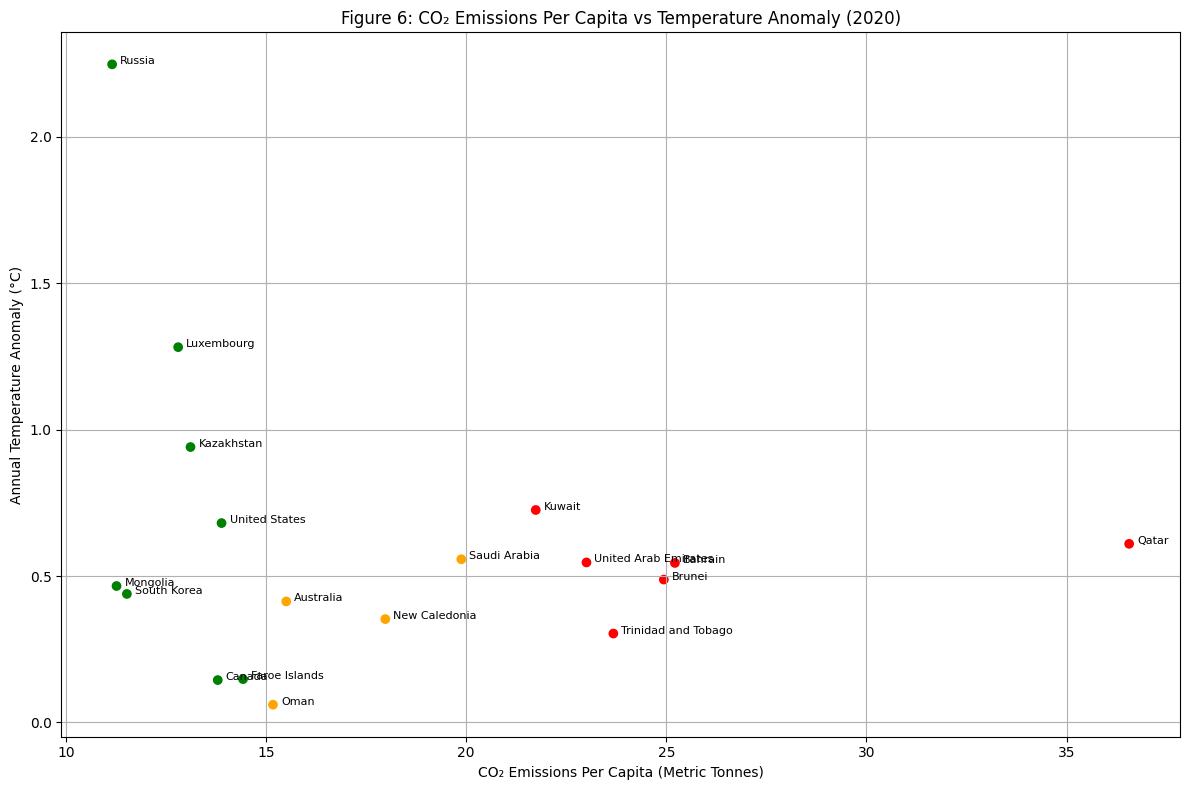

In [28]:
#Step 7.4.2 Scatterplot of CO2 vs Temperature Anomaly (2020)
colours = ['red' if v > 20
           else 'orange' if v > 15
           else 'green'
           for v in temp_co2_2020['CO2 Emissions Per Capita']] #V = value

plt.figure(figsize=(12, 8))
plt.scatter(temp_co2_2020['CO2 Emissions Per Capita'],
            temp_co2_2020['Annual Temperature Anomaly'],
            color=colours)

# Labelling each country point directly
for _, row in temp_co2_2020.iterrows():
    plt.text(row['CO2 Emissions Per Capita'] + 0.2, #Added 0.2 so it's slightly off to the side and not directly atop the coloured dots
             row['Annual Temperature Anomaly'],
             row['Country Name'], fontsize=8)

plt.title('Figure 6: CO₂ Emissions Per Capita vs Temperature Anomaly (2020)')
plt.xlabel('CO₂ Emissions Per Capita (Metric Tonnes)')
plt.ylabel('Annual Temperature Anomaly (°C)')
plt.grid(True)
plt.tight_layout()
plt.savefig('fig6_scatter_co2_temp.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
#Step 8: Inference Practice
# PURPOSE:
#   Apply Modus Ponens-style inference rules to every country for a specific year-range
#   and classify each one into a recommended climate policy tier that focuses on what is the main concern (CO2 emissions OR temperature), for international policymakers.

#Step 8.1 Creating a function for policy inference to recommend to policymakers which countries are eligible for specific ones. Get_country_data() is reused here.
def check_climate_policy(country_df):
    """
    Recommends a climate policy tier for a given country.
    Takes the output of get_country_data() as its input.

    Parameters:
    country_df : the DataFrame returned by get_country_data() (DataFrame)

    Example usage:
    data = get_country_data(cleaned_df, "Australia", 2020, 2020)
    check_climate_policy(data)
    """
 # Read the values directly from the DataFrame row
    # I use .mean() so it still works if a year range with multiple rows is passed in
    country = country_df['Country Name'].iloc[0]
    co2_emissions = country_df['CO2 Emissions Per Capita'].mean()
    temp_anomaly  = country_df['Annual Temperature Anomaly'].mean()

    print(f"\n--- Policy Check: {country} ---")
    print(f"CO2 Emissions: {co2_emissions:.2f} MT per capita")
    print(f"Temperature Anomaly: {temp_anomaly:.2f} °C")

    #Decision tree pipeline
    if co2_emissions > 10: #Is CO2 above 10 metric tonnes)
        if temp_anomaly >= 1.5:
            classification = "Policy RED - Urgent intervention needed for both emissions and climate temperature"
        elif temp_anomaly >= 0.5:
            classification = "Policy ORANGE - Emissions reduction plan required"
        else:
            classification = "Policy YELLOW - Emissions reduction plan recommended"
    else: #If CO2 is low but temp is still high
        if temp_anomaly >= 1.5:
            classification = "Policy GREEN - Climate adaptation plans required"
        else: #Countries that don't fall under either conditions)
            classification = "Continue monitoring"
    print(f"Classification: {classification}")

    #Inference chain table
    print("\n--- Truth Table Output ---")
    print("CO2 above 10 MT (double global avg of 4.34 MT):", co2_emissions > 10)
    print("Temp at or above Paris threshold (1.5 degrees C):", temp_anomaly >= 1.5)
    print("High CO2 AND above Paris threshold:", co2_emissions > 10 and temp_anomaly >= 1.5)


In [30]:
#Step 8.2 Testing the check_climate_policy function
russia_data = get_country_data(cleaned_df, "Russia", 2020, 2020)
check_climate_policy(russia_data)



--- Policy Check: Russia ---
CO2 Emissions: 11.16 MT per capita
Temperature Anomaly: 2.25 °C
Classification: Policy RED - Urgent intervention needed for both emissions and climate temperature

--- Truth Table Output ---
CO2 above 10 MT (double global avg of 4.34 MT): True
Temp at or above Paris threshold (1.5 degrees C): True
High CO2 AND above Paris threshold: True


In [31]:
"""Filtered DataFrames"""
#main_df = Original dataset
#cleaned_df = Filtered dataset, no country code column, no rows with NaN values in Annual Temperature Anomaly
#top_co2_2020 ->  countries where CO₂ emissions per capita exceed 10 in 2020 from country_co2_2020
#country_co2_2020 -> average CO₂ emissions per capita per country in 2020, sorted lowest to highest
#countries_co2_above_10_2020 -> countries with CO₂ emissions above 10 per capita in 2020, sorted highest to lowest
#exceeding ->  all country-year records where Annual Temperature Anomaly exceeds the Paris Agreement threshold
#aggregated_temp_per_year -> mean, min, and max Annual Temperature Anomaly per year across all countries

"""Filtered subsets"""
#missing_years -> Years where Annual Temperature Anomaly data is missing
#total_countries -> total no. of unique countries in the dataset
#data_gap_countries ->  Number of countries with at least one missing Annual Temperature Anomaly value
#countries_set -> Set that contains only unique country names
#global_avg_co2_2020 -> Global average CO₂ emissions per capita across all countries in 2020
#theoretical_max ->  Expected total records if every country has data for every year
#average_global_temp_by_year -> Global average Annual Temperature Anomaly per year — aggregated across all countries

"""Series"""
#combos ->  Count of records per unique Country-Year combination


'Series'

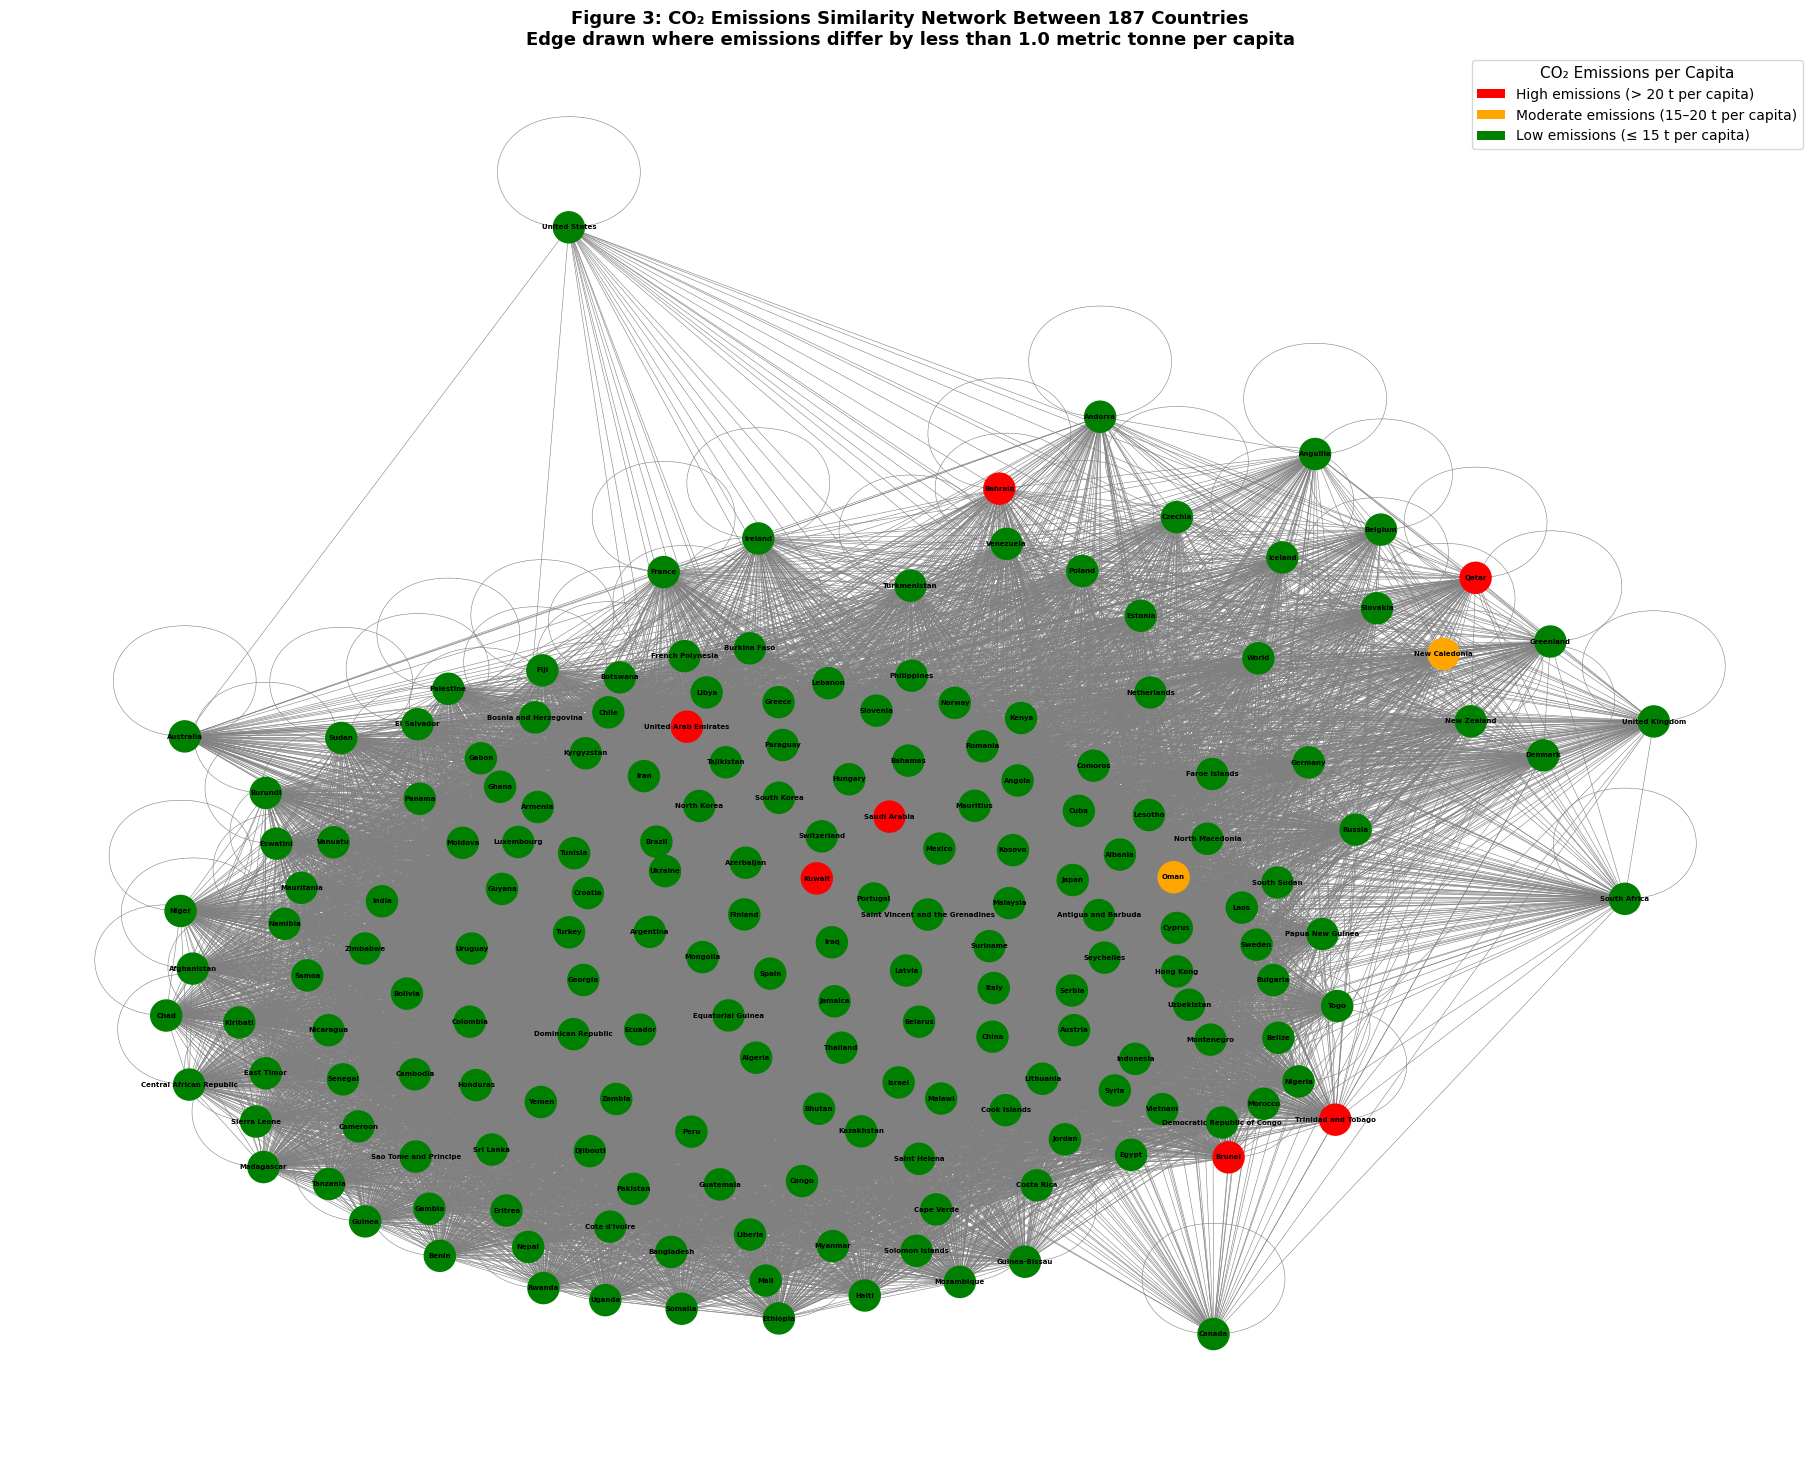

Number of nodes (countries): 187
Number of edges (similar pairs): 15456
Isolated nodes (no similar peers): 0


In [47]:
from matplotlib.patches import Patch

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G_all_countries, seed=42, k=0.8)

node_colours = [
    'red'    if G_all_countries.nodes[node]['co2'] > 20
    else 'orange' if G_all_countries.nodes[node]['co2'] > 15
    else 'green'
    for node in G_all_countries.nodes
]

nx.draw(G_all_countries, pos, with_labels=True, node_color=node_colours,
        node_size=500,   # Played around with sizes for a bit, this one is the least visually cluttering size
        font_size=5,     # Reduced — 187 labels at size 8 overlap in a unreadable and ugly way
        font_weight='bold', edge_color='grey',
        width=0.4,       # Thinner — hundreds of edges at width 1.5 looks like a solid black blob
        )

# Legend — explains node colour thresholds for CO₂ emissions per capita
legend = [
    Patch(facecolor='red',    label='High emissions (> 20 t per capita)'),
    Patch(facecolor='orange', label='Moderate emissions (15–20 t per capita)'),
    Patch(facecolor='green',  label='Low emissions (≤ 15 t per capita)'),
]
plt.legend(handles=legend, loc='upper right', fontsize=10,
           title='CO₂ Emissions per Capita', title_fontsize=11)

plt.title('Figure 3: CO₂ Emissions Similarity Network Between 187 Countries\n'
          'Edge drawn where emissions differ by less than 1.0 metric tonne per capita',
          fontsize=13, fontweight='bold')
plt.savefig('fig3_full_network_graph.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Number of nodes (countries): {G_all_countries.number_of_nodes()}")
print(f"Number of edges (similar pairs): {G_all_countries.number_of_edges()}")
print(f"Isolated nodes (no similar peers): {len(list(nx.isolates(G_all_countries)))}")

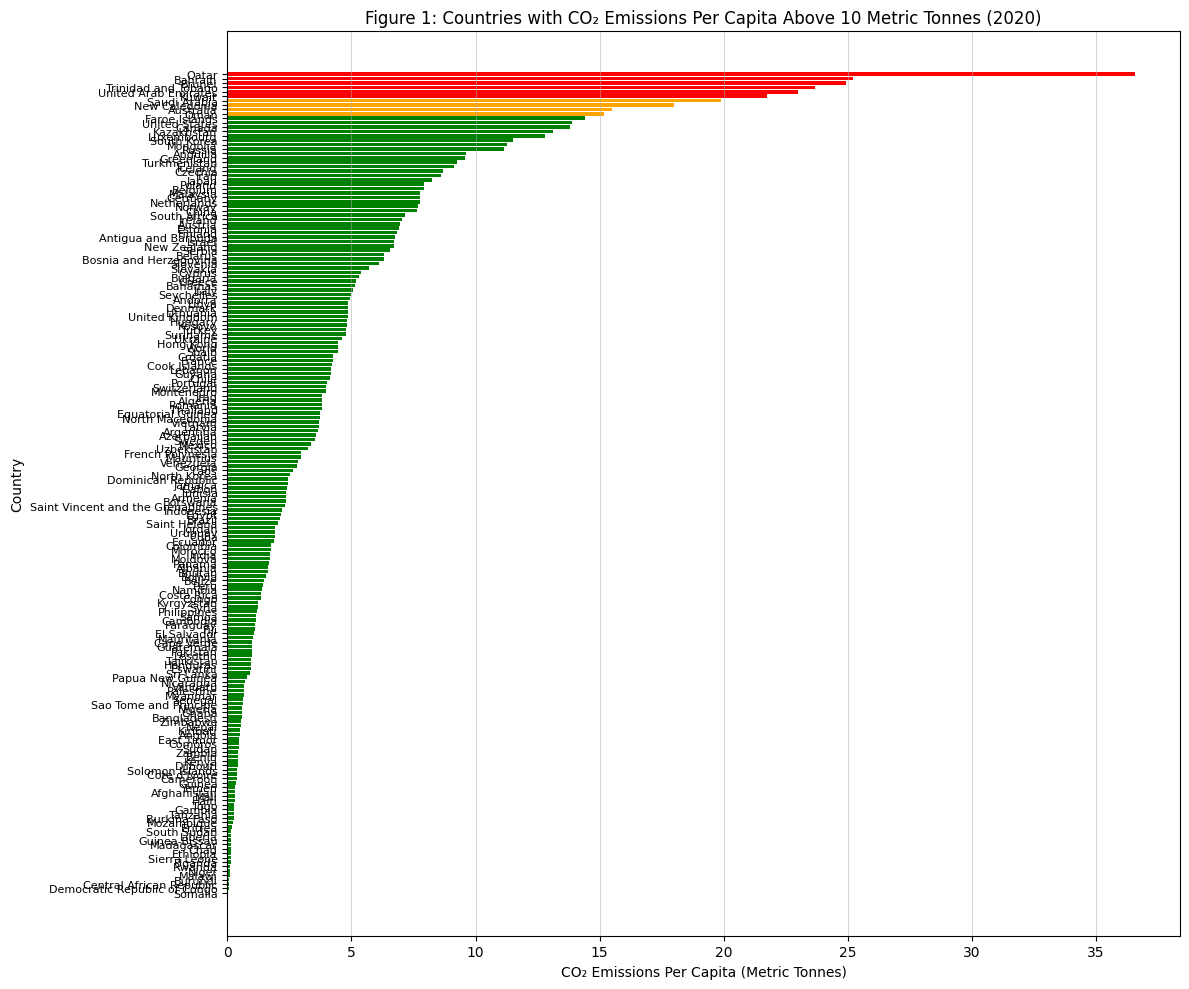

In [50]:
# Sort by emissions descending so highest emitters appear at top
country_co2_2020 = country_co2_2020.sort_values('CO2 Emissions Per Capita', ascending=True)

colours = ['red' if v > 20
           else 'orange' if v > 15
           else 'green'
           for v in country_co2_2020['CO2 Emissions Per Capita']]

plt.figure(figsize=(12, 10))  # Taller figure — gives each bar more vertical breathing room
plt.barh(country_co2_2020['Country Name'], country_co2_2020['CO2 Emissions Per Capita'], color=colours)
plt.title('Figure 1: Countries with CO₂ Emissions Per Capita Above 10 Metric Tonnes (2020)')
plt.xlabel('CO₂ Emissions Per Capita (Metric Tonnes)')
plt.ylabel('Country')
plt.yticks(fontsize=8)  # Smaller font so country labels don't overlap
plt.grid(axis='x', alpha=0.5)  # Softer gridlines — less visual noise
plt.tight_layout()
plt.savefig('fig1_bar_co2_emitters.png', dpi=150, bbox_inches='tight')
plt.show()

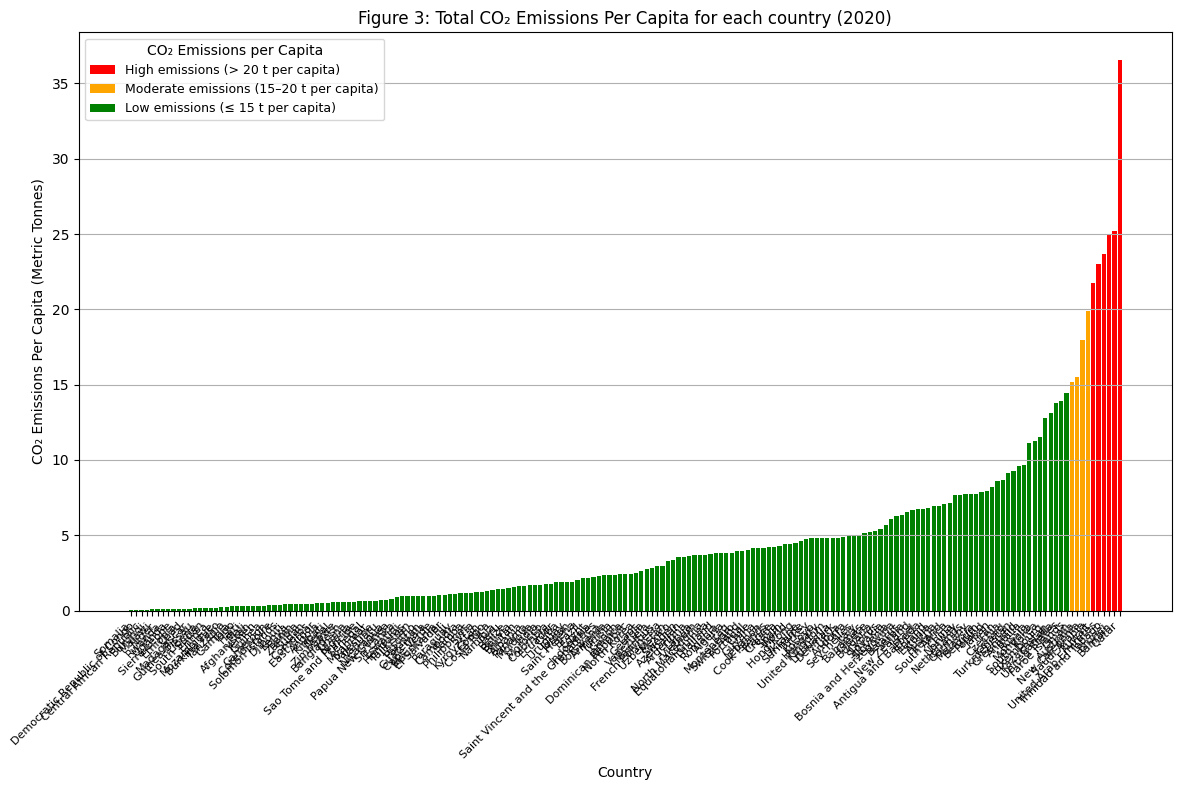

In [61]:
# Step 7.3.1 Creating the bar chart
# Colour coded to match network graph from Step 6 — red above 20t, orange 15-20t, green 10-15t
colours = ['red' if v > 20 
           else 'orange' if v > 15 
           else 'green' 
           for v in country_co2_2020['CO2 Emissions Per Capita']]
plt.figure(figsize=(12, 8))
plt.bar(country_co2_2020['Country Name'], country_co2_2020['CO2 Emissions Per Capita'], color=colours)
plt.title('Figure 3: Total CO₂ Emissions Per Capita for each country (2020)')
plt.xlabel('Country')
plt.ylabel('CO₂ Emissions Per Capita (Metric Tonnes)')
plt.xticks(rotation=45, ha='right', fontsize=8)  # Angled labels so country names don't overlap
plt.grid(axis='y')

legend = [
    Patch(facecolor='red',    label='High emissions (> 20 t per capita)'),
    Patch(facecolor='orange', label='Moderate emissions (15–20 t per capita)'),
    Patch(facecolor='green',  label='Low emissions (≤ 15 t per capita)'),
]
plt.legend(handles=legend, loc='upper left', fontsize=9,
           title='CO₂ Emissions per Capita', title_fontsize=10)

plt.tight_layout()
plt.savefig('fig3_bar_co2_2020_emitters.png', dpi=150, bbox_inches='tight')
plt.show()

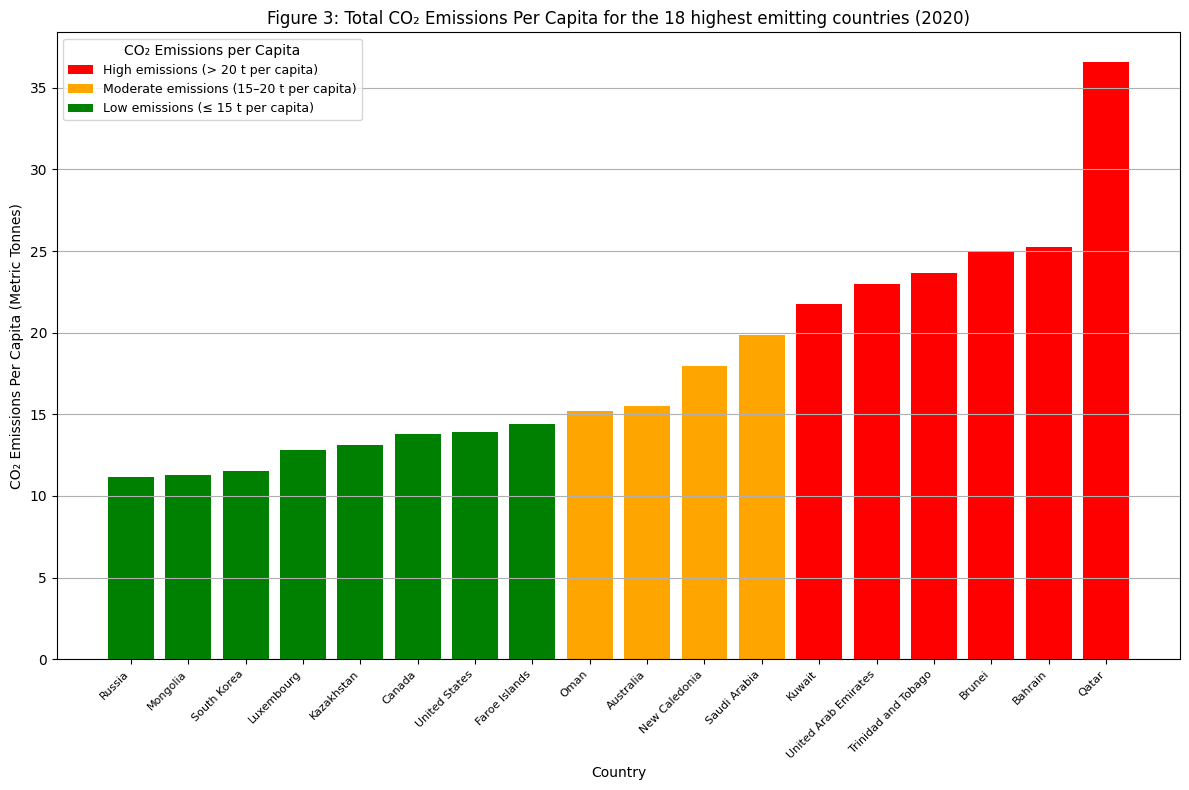

In [62]:
# Step 7.3.1 Creating the bar chart
# Colour coded to match network graph from Step 6 — red above 20t, orange 15-20t, green 10-15t
colours = ['red' if v > 20 
           else 'orange' if v > 15 
           else 'green' 
           for v in top_co2_2020['CO2 Emissions Per Capita']]
plt.figure(figsize=(12, 8))
plt.bar(top_co2_2020['Country Name'], top_co2_2020['CO2 Emissions Per Capita'], color=colours)
plt.title('Figure 3: Total CO₂ Emissions Per Capita for the 18 highest emitting countries (2020)')
plt.xlabel('Country')
plt.ylabel('CO₂ Emissions Per Capita (Metric Tonnes)')
plt.xticks(rotation=45, ha='right', fontsize=8)  # Angled labels so country names don't overlap
plt.grid(axis='y')

legend = [
    Patch(facecolor='red',    label='High emissions (> 20 t per capita)'),
    Patch(facecolor='orange', label='Moderate emissions (15–20 t per capita)'),
    Patch(facecolor='green',  label='Low emissions (≤ 15 t per capita)'),
]
plt.legend(handles=legend, loc='upper left', fontsize=9,
           title='CO₂ Emissions per Capita', title_fontsize=10)

plt.tight_layout()
plt.savefig('fig3_bar_top_co2_2020_emitters.png', dpi=150, bbox_inches='tight')
plt.show()


In [55]:
# Step 7.3 Creating variable that stores CO2 emissions for each country in 2020
country_co2_2020 = (
    cleaned_df[cleaned_df['Year'] == 2020]
    .groupby('Country Name')['CO2 Emissions Per Capita']
    .mean()  
    .sort_values(ascending=True)  # Ascending for horizontal readability
    .reset_index()
)

print(country_co2_2020.columns)

Index(['Country Name', 'CO2 Emissions Per Capita'], dtype='str')


In [56]:
print(cleaned_df.columns)

Index(['Country Name', 'Year', 'CO2 Emissions Per Capita',
       'Annual Temperature Anomaly'],
      dtype='str')


In [60]:
#Step 7.4 Adding temperature with filtered dataframe that contains only the 2020 rows
# Reusing country_co2_2020 from Step 7.3 
temp_co2_2020 = cleaned_df[
    (cleaned_df['Year'] == 2020) &
    (cleaned_df['Country Name'].isin(country_co2_2020['Country Name']))
].reset_index(drop=True)
print(temp_co2_2020)

    Country Name  Year  CO2 Emissions Per Capita  Annual Temperature Anomaly
0    Afghanistan  2020                  0.297063                   -0.171064
1        Albania  2020                  1.640428                    0.708608
2        Algeria  2020                  3.818575                    1.017536
3        Andorra  2020                  4.926832                    0.394073
4         Angola  2020                  0.494244                    0.401648
..           ...   ...                       ...                         ...
182      Vietnam  2020                  3.695583                    0.518624
183        World  2020                  4.453724                    0.432163
184        Yemen  2020                  0.301205                    0.108743
185       Zambia  2020                  0.427315                    0.137313
186     Zimbabwe  2020                  0.547085                    0.229293

[187 rows x 4 columns]


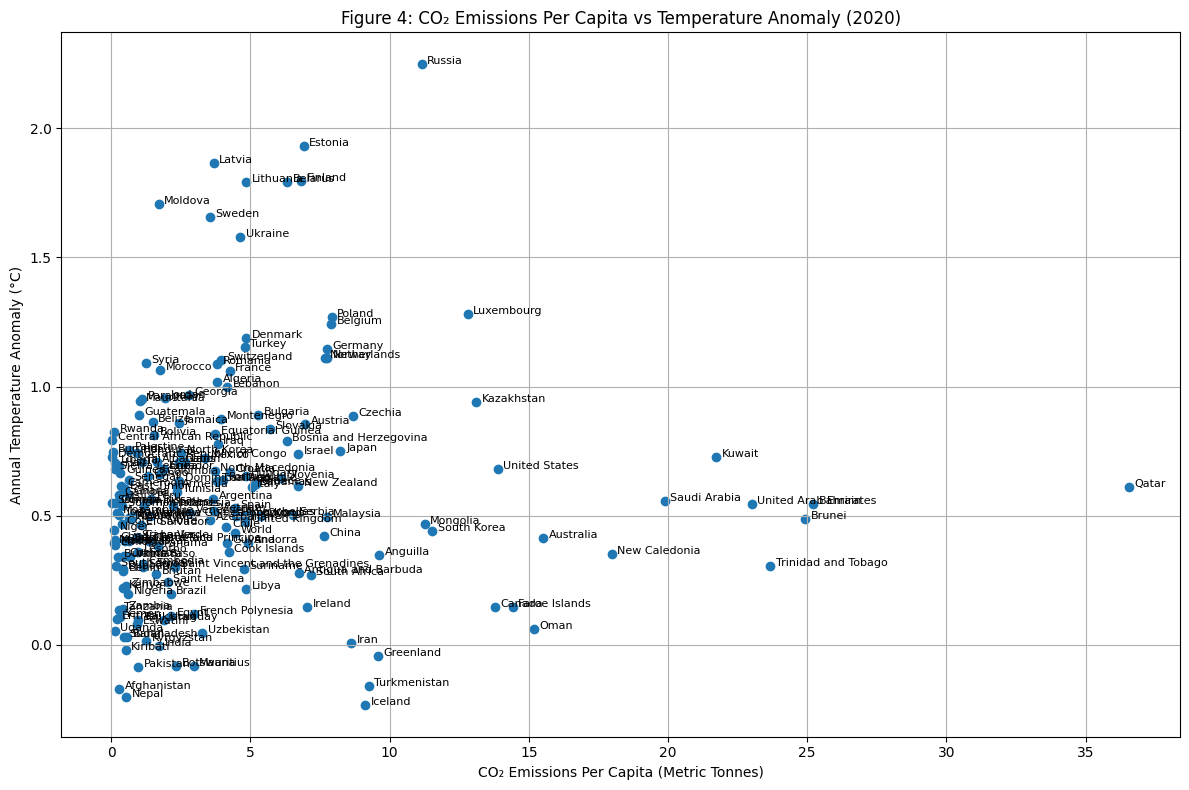

In [69]:
#Step 7.4.2 Scatterplot of CO2 vs Temperature Anomaly (2020)
plt.figure(figsize=(12, 8))
plt.scatter(temp_co2_2020['CO2 Emissions Per Capita'],
            temp_co2_2020['Annual Temperature Anomaly'],
            )

# Labelling each country point directly
for _, row in temp_co2_2020.iterrows():
    plt.text(row['CO2 Emissions Per Capita'] + 0.2, #Added 0.2 so it's slightly off to the side and not directly atop the coloured dots
             row['Annual Temperature Anomaly'],
             row['Country Name'], fontsize=8)

plt.title('Figure 4: CO₂ Emissions Per Capita vs Temperature Anomaly (2020)')
plt.xlabel('CO₂ Emissions Per Capita (Metric Tonnes)')
plt.ylabel('Annual Temperature Anomaly (°C)')
plt.grid(True)

plt.tight_layout()
plt.savefig('fig4_scatter_co2_temp.png', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
print(country_co2_2020)

                     Country Name  CO2 Emissions Per Capita
0                         Somalia                  0.035867
1    Democratic Republic of Congo                  0.044812
2        Central African Republic                  0.047380
3                         Burundi                  0.058576
4                          Malawi                  0.090518
..                            ...                       ...
182          United Arab Emirates                 23.006842
183           Trinidad and Tobago                 23.677786
184                        Brunei                 24.939121
185                       Bahrain                 25.215979
186                         Qatar                 36.564110

[187 rows x 2 columns]
